<a href="https://colab.research.google.com/github/Sameekshaingole/fraud-detection-federated-learning/blob/main/Baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BASELINE MODEL (CENTRALIZED)

Mounted at /content/drive
All libraries imported successfully!

Loading data from Google Drive...
Data loaded successfully!
DATASET INFORMATION
X_train shape : (555902, 224)
X_test shape  : (118108, 224)
y_train shape : (555902,)
y_test shape  : (118108,)
Fraud in train: 100000
Fraud in test : 4133

Training Simple Centralized Random Forest Baseline...
Please wait...
Training completed in 28.25 seconds!

Making predictions on test data...

 WEAKER CENTRALIZED BASELINE RESULTS
Threshold        : 0.5
Accuracy         : 0.9673
Precision        : 0.6006
Recall           : 0.195
F1 Score         : 0.2944
ROC-AUC Score    : 0.8186
Training Time    : 28.25 seconds
Predicted Fraud  : 1342
Actual Fraud     : 4133

Classification Report:

              precision    recall  f1-score   support

   Not Fraud       0.97      1.00      0.98    113975
       Fraud       0.60      0.20      0.29      4133

    accuracy                           0.97    118108
   macro avg       0.79      0.60      0.64

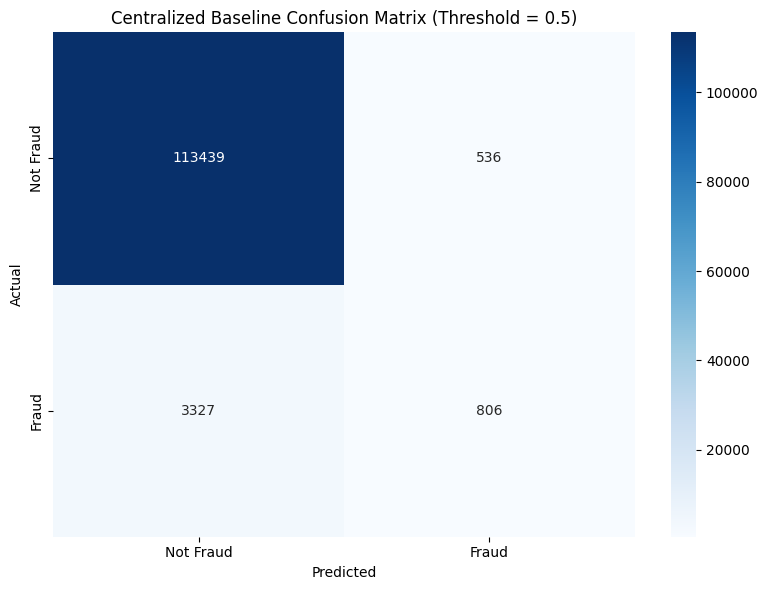

Confusion matrix saved successfully!
Baseline model saved as baseline_model_simple.pkl
Baseline results saved as baseline_results_simple.txt

Baseline model process completed successfully!


In [ ]:
# =========================
# BASELINE MODEL (WEAKER CENTRALIZED VERSION)
# =========================

from google.colab import drive
drive.mount('/content/drive')

# =========================
# IMPORT LIBRARIES
# =========================
import numpy as np
import pickle
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

# =========================
# LOAD PREPROCESSED DATA
# =========================
print("\nLoading data from Google Drive...")

X_train = np.load('/content/drive/MyDrive/fraud_detection_project/X_train.npy')
X_test  = np.load('/content/drive/MyDrive/fraud_detection_project/X_test.npy')
y_train = np.load('/content/drive/MyDrive/fraud_detection_project/y_train.npy')
y_test  = np.load('/content/drive/MyDrive/fraud_detection_project/y_test.npy')

print("Data loaded successfully!")
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)
print("Fraud in train:", int(y_train.sum()))
print("Fraud in test :", int(y_test.sum()))
print("=" * 50)

# =========================
# TRAIN BASELINE MODEL
# =========================
print("\nTraining Simple Centralized Random Forest Baseline...")
print("Please wait...")

start = time.time()

# Intentionally simple / weaker baseline
rf_model = RandomForestClassifier(
    n_estimators=25,         # less trees
    max_depth=4,             # shallower trees
    min_samples_split=25,    # more conservative
    min_samples_leaf=15,     # more conservative
    max_features='sqrt',
    bootstrap=True,
    class_weight=None,       # no imbalance handling
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

training_time = time.time() - start
print(f"Training completed in {round(training_time, 2)} seconds!")

# =========================
# PREDICTION
# =========================
print("\nMaking predictions on test data...")

y_prob = rf_model.predict_proba(X_test)[:, 1]

# SAME threshold (fair baseline)
threshold = 0.50
y_pred = (y_prob >= threshold).astype(int)

# =========================
# EVALUATION METRICS
# =========================
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_prob)

print("\n" + "=" * 50)
print(" WEAKER CENTRALIZED BASELINE RESULTS")
print("=" * 50)
print(f"Threshold        : {threshold}")
print(f"Accuracy         : {round(accuracy, 4)}")
print(f"Precision        : {round(precision, 4)}")
print(f"Recall           : {round(recall, 4)}")
print(f"F1 Score         : {round(f1, 4)}")
print(f"ROC-AUC Score    : {round(roc_auc, 4)}")
print(f"Training Time    : {round(training_time, 2)} seconds")
print("=" * 50)
print(f"Predicted Fraud  : {y_pred.sum()}")
print(f"Actual Fraud     : {int(y_test.sum())}")
print("=" * 50)

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Fraud', 'Fraud']
))

# =========================
# CONFUSION MATRIX
# =========================
print("\nGenerating confusion matrix...")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Fraud', 'Fraud'],
    yticklabels=['Not Fraud', 'Fraud']
)

plt.title(f'Centralized Baseline Confusion Matrix (Threshold = {threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_detection_project/baseline_confusion_matrix_simple.png')
plt.show()

print("Confusion matrix saved successfully!")

# =========================
# SAVE MODEL
# =========================
with open('/content/drive/MyDrive/fraud_detection_project/baseline_model_simple.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Baseline model saved as baseline_model_simple.pkl")

# =========================
# SAVE RESULTS TO TXT
# =========================
results_text = f"""
BASELINE MODEL RESULTS
======================
Model      : Simple Centralized Random Forest
Dataset    : IEEE-CIS Fraud Detection
Train size : {X_train.shape[0]}
Test size  : {X_test.shape[0]}
Threshold  : {threshold}

Accuracy   : {round(accuracy, 4)}
Precision  : {round(precision, 4)}
Recall     : {round(recall, 4)}
F1 Score   : {round(f1, 4)}
ROC-AUC    : {round(roc_auc, 4)}
Train Time : {round(training_time, 2)} seconds

Predicted fraud : {y_pred.sum()}
Actual fraud    : {int(y_test.sum())}
"""

with open('/content/drive/MyDrive/fraud_detection_project/baseline_results_simple.txt', 'w') as f:
    f.write(results_text)

print("Baseline results saved as baseline_results_simple.txt")
print("\nBaseline model process completed successfully!")